In [117]:
import sys
import os
import numpy as np
import torch
git_path='/mnt/home/ipark/git/ml-dmft-fork/mlDMFT/'
sys.path.append(git_path)
# from mldmft.models.orb3.NNet import FeedforwardNet
sys.path.append('./')
from NNet import FeedforwardNet

from triqs.gf import *
import triqs.operators.util as op
from h5 import *
from lib_3orb import *

In [2]:
# path=os.path.join(git_path, 'mldmft')
# # print(path)

In this example, we will perform DMFT calculation for 3-orbital impurity on the Bethe lattice with a semicircular density of states (with half-bandwidth $D$) using $G$Net solver, a neural-network solver trained for $M=3$ orbitals at $\beta=10$. 


## I. NN-DMFT Loop

### 1) Set parameters and build hybridization functionfor DMFT calculation
We start by building an hyrbidization function $\Delta$ and picking interaction parameter $U$, $J$ and chemical potential $\mu$. For self-consistent DMFT calculation, we also specify the tolarence of impurity occupancy $n_{imp}$ for the DMFT convergence criterion and the maximum number of self-consistent DMFT loops. One can also set the mixing parameter $\epsilon$, which is used to update hybridization function in the DMFT self-consistent loop via 
$$ \Delta_{\rm new} = (1-\epsilon) \Delta_i + \epsilon \Delta_{i-1}. $$  

First, we will set parameters:  

In [193]:
# Config
t = 1
U = 6.0
J = 0.6
mu = 2.0
beta = 10.0

half_bandwidth = 0.3

wmax = 10.0
eps  = 1e-13

maxloops = 50   # number of DMFT iterations
etol = 1e-4     # DMFT SC loop convergence criteria, occupancy from G
epsilon = 0.05  # Delta mixing parameter

save_tofile = True

TRIQS offers a convenient way to build a hybridization function of a semicircular density of states with given bandwidth (or kinetic energy.)  In this example, we will start from building a hybrdization function of a half-bandwidth $D$ in Matsubara frequency mesh and convert it into a function on DLR imaginary frequency mesh. Then we will convert it into NN-input format.  

In mutli-orbital case, the hybridization or the Green's function is $2 \times M \times M$ block matrices ($2$ for spin-up and spin-down), and in the NN model, the input will be composed of the upper triangular part of the block matrix, i.e.   
$$ \left[  \right] $$

In [194]:
# System
n_orb = 3
pairs = list(zip(*np.triu_indices(n_orb)))
ntri = len(pairs)
spin_names = ['up', 'down']
gf_struct = op.set_operator_structure(spin_names, n_orb, off_diag=True)


#Load NN mesh
# h5_mesh = os.path.join(git_path,'mldmft/examples/3orbital/mesh_beta10.0.h5') 
h5_mesh = '/mnt/ceph/users/ipark/ML/git-example/bethe-nn/mesh_beta10.0.h5'
with HDFArchive(h5_mesh ,'r') as h5:
    mesh = h5['mesh_dlr_imtime']
ntau = len(mesh)

#Intial Hybridization function
Delta_tau = build_initial_delta(beta, half_bandwidth, gf_struct)

delta_nn_mesh, Delta_dlr_imtime = project_to_nn_mesh(
    Delta_tau, mesh, gf_struct, wmax, eps, pairs
)

#Build NN input
train_data = blockgf_to_nn_input(
    Delta_dlr_imtime,
    mesh,
    pairs
)
# print(train_data.shape)
NNinput = build_nn_feature_vector(train_data, U, mu, J)
# print(NNinput.shape)

#### 1-1) Plot input hybridization function

/tmp/ipykernel_375845/1285962851.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right').set_visible(False)


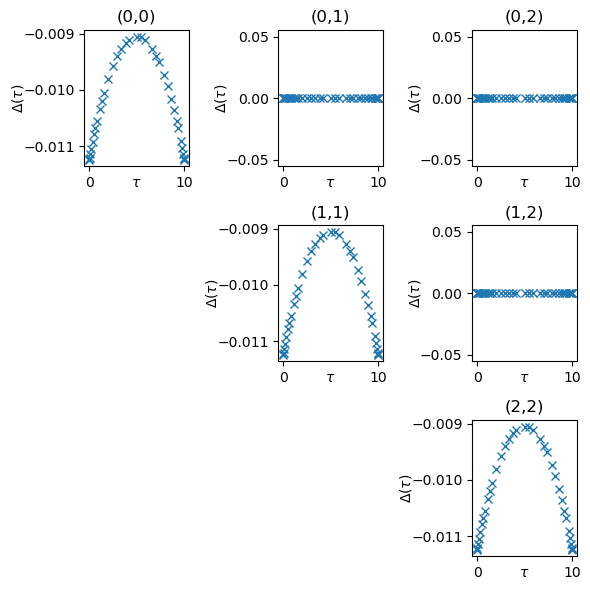

In [195]:
import matplotlib.pyplot as plt 
from triqs.plot.mpl_interface import oplot

taus = np.array([float(t) for t in Delta_dlr_imtime['up'].mesh])
np.save('tauvals.npy', taus)

fig, axes = plt.subplots(n_orb, n_orb, figsize=(6,6)) 
plt.subplots_adjust(wspace=0.35, hspace=0.4)

for i in range(n_orb):
    for j in range(n_orb):
        ax = axes[i, j]
        if i<= j:
            delta = Delta_dlr_imtime['up']
            ax.oplot(delta[i,j].real, label='Re', zorder=99)
            # ax.oplot(delta[i,j].imag, label='Im', zorder=99)
    
            ax.set_title(f'({i},{j})')
    
        else:
            ax.axis("off")

        ax.legend(loc='upper right').set_visible(False)
        ax.set_xlabel(r'$\tau$', labelpad=-10)
        ax.set_ylabel(r'$\Delta(\tau)$', labelpad=-2)
        
plt.tight_layout()
plt.show()

Next, we load the neural-network model and the stored checkpoints.

### 2) Load NN Model

In [196]:
device = torch.device('cpu')

# load model
# path_load = os.path.join(path, 'models/orb3/')
feedforwardnet = FeedforwardNet()
feedforwardnet.to(device)
# feedforwardnet.load_state_dict(torch.load(os.path.expanduser(os.path.join(path_load, "save_10000.pth")), map_location=device, weights_only=True))
feedforwardnet.load_state_dict(torch.load("./save_10000.pth", map_location=device, weights_only=True))
feedforwardnet.eval()

FeedforwardNet(
  (fc1): Linear(in_features=435, out_features=1024, bias=True)
  (resblock1): Sequential(
    (0): Linear(in_features=1024, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=2048, bias=True)
    (3): ReLU()
    (4): Linear(in_features=2048, out_features=1024, bias=True)
  )
  (resblock2): Sequential(
    (0): Linear(in_features=1024, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=2048, bias=True)
    (3): ReLU()
    (4): Linear(in_features=2048, out_features=1024, bias=True)
  )
  (fc2): Linear(in_features=1024, out_features=432, bias=True)
)

### 3) DMFT loop
Now, we run a DMFT loop on the Bethe lattice, i.e. with the self-consistency $ \Delta_{i+1} = t^2 G_{i} $, where $t=1$.

In [197]:
Goutput_prev = None 
Goutput_eps = None
converged = False
verbose = True
save_tofile = False 
conv_check = None

NN_current_dmft = np.copy(NNinput)
G_dmft = {}

batchsize = 1
ndlr_taus = len(mesh) #(NN_current_dmft.shape[-1]-3)//2

for iloop in range(maxloops):

        Goutput = feedforwardnet((torch.from_numpy(NN_current_dmft).float()).to(device)).detach().cpu().numpy()
        if Goutput_prev is None:
            Goutput_prev = np.copy(Goutput)
            Goutput_eps = np.copy(Goutput)
        else: 
            conv_check = np.linalg.norm(Goutput - Goutput_prev)
            if verbose:
               print(f"Iteration {iloop}, convergence check: {conv_check}")
            if (conv_check < 1.0e-5):
                print("Convergence reached at iteration ", iloop)
                converged = True
                break
            Goutput_prev = np.copy(Goutput)
            Goutput_eps = (1-epsilon)*Goutput + epsilon*Goutput_prev
        outputvals = np.zeros((batchsize, ntau*2*ntri+3))
        outputvals[:,-3]= U
        outputvals[:,-2]= mu/U
        outputvals[:,-1]= J
        outputvals[:,:-3] = t**2 * np.reshape(Goutput_eps, (1, ntau*2*ntri))
        
        NN_current_dmft = outputvals 
        # outputs = np.reshape(Goutput, (Goutput.shape[0], ntau, ntri, 2))
        outputs = nn_output_to_channel_array(Goutput[0], ntau, ntri)[None, ...]
        if conv_check is not None:
           G_dmft[iloop] = {"conv error": conv_check, "G": outputs}
        if save_tofile:
            np.save(f"dmft_NN/dmft_NN_it{iloop}.npy", outputs)

G_dmft["final"] = {"conv error": conv_check, "G": outputs}
G_dmft["n_its"] = iloop 

if not converged:
    print(f"DMFT loop has not converged, the final convergence check error is {conv_check}. \
    Change mixing parameter $\epsilon$, increase the number of maximum iterations or try a \
    different initial hybridization function $\Delta$. ")

if save_tofile:
    if not os.path.exists("dmft_NN"):
        os.makedirs("dmft_NN")
    
    np.save("dmft_NN/dmft_NN_final.npy", outputs)
    np.save("dmft_NN/beta.npy", beta)
    np.save("dmft_NN/mu.npy", mu)
    np.save("dmft_NN/U.npy", Uval)
        

Iteration 1, convergence check: 0.20241886377334595
Iteration 2, convergence check: 0.11007698625326157
Iteration 3, convergence check: 0.12907154858112335
Iteration 4, convergence check: 0.16173751652240753
Iteration 5, convergence check: 0.1354125589132309
Iteration 6, convergence check: 0.05000746622681618
Iteration 7, convergence check: 0.005611673928797245
Iteration 8, convergence check: 0.0011373215820640326
Iteration 9, convergence check: 0.00034746297751553357
Iteration 10, convergence check: 0.00022005807841196656
Iteration 11, convergence check: 9.838729602051899e-05
Iteration 12, convergence check: 4.032746437587775e-05
Iteration 13, convergence check: 3.1248950108420104e-05
Iteration 14, convergence check: 1.5006748981249984e-05
Iteration 15, convergence check: 5.627661266771611e-06
Convergence reached at iteration  15


### 4) Plot results 

#### 4-1) NN output

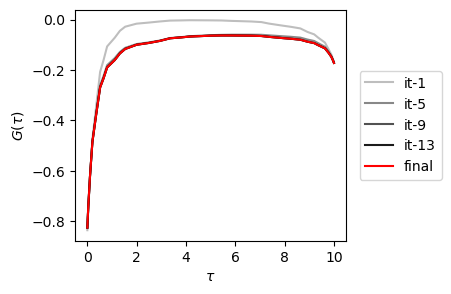

In [198]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
for iloop in range(1, G_dmft["n_its"]):
    if iloop in np.arange(1,20,4):
        ax.plot(taus, G_dmft[iloop]["G"][0,:, 0], color = 'black', alpha = iloop/G_dmft["n_its"]*0.8 + 0.2, label=f'it-{iloop}') 

ax.plot(taus, G_dmft["final"]["G"][0,:, 0],  color = 'red', label='final')
ax.set_xlabel(r"$\tau$") 
ax.set_ylabel(r"$G(\tau)$")
ax.legend(loc='center', bbox_to_anchor=(1.2,0.5))
plt.savefig("Gtau.png")

#### 4-2) In BlockGf object

In [199]:
G_tau = nn_channels_to_blockgf(
    G_dmft[iloop]["G"][0],
    delta_nn_mesh,
    pairs
)

G_tau_imtime = make_gf_imtime(G_tau, n_tau=101)

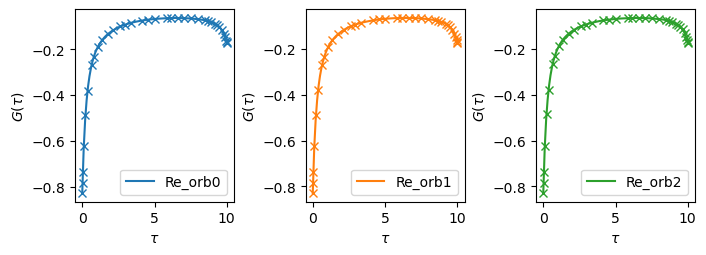

In [200]:
import matplotlib.colors as cm

colors = [cm.to_hex(plt.cm.tab10(i)) for i in range(n_orb)]
lines = ['-', '--']


# fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
fig, axs = plt.subplots(1, 3, figsize=(8,2.5), dpi=100)
plt.subplots_adjust(wspace=0.45)
for i in range(n_orb):
    ax=axs[i]
    ax.oplot(G_tau_imtime['up'][i,i].real, color=colors[i], linestyle=lines[0], label=f'Re_orb{i}') 
    ax.oplot(G_tau['up'][i,i].real, 'x', color=colors[i], linestyle=lines[0], label=f'') 
    
    ax.set_xlabel(r"$\tau$") 
    ax.set_ylabel(r"$G(\tau)$")
    ax.legend(loc='lower right')
    plt.savefig("Gtau_conv.png")

#### 4-3) Plot $G(i\omega)$

We can easily convert $G(\tau)$ in DLR imaginary time mesh to DLR imaginary frequency or full imaginary frequency mesh using TRIQS library.

In [201]:
G_iw = make_gf_dlr_imfreq(G_tau)
G_iw_imfreq = make_gf_imfreq(G_iw, n_iw=1001)

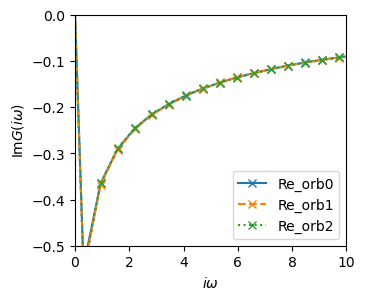

In [202]:
colors = [cm.to_hex(plt.cm.tab10(i)) for i in range(n_orb)]
lines = ['-', '--', ':']


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
for i in range(n_orb):
    ax.oplot(G_iw_imfreq['up'][i,i].imag, 'x', color=colors[i], linestyle=lines[i], label=f'Re_orb{i}') 
ax.set_xlim(0,10)
ax.set_ylim(-0.5,0)
ax.set_xlabel(r"$i\omega$") 
ax.set_ylabel(r"Im$G(i\omega)$")
ax.legend(loc='lower right') 
plt.savefig("Giom_conv.png")

## II. Comparison to CT-SEG results

### 1) Load CT-HYB results  

* taus: imaginary time mesh from CTHYB
* vals: $G(tau)$ matrix for `up' spin, in shape of (tau, orb-i, orb-j).

In [203]:
taus = np.load('taus.npy')
vals = np.load('G_tau_imtime.npy')

### 2) Compare NN vs CT-HYB : Impurity Green's function in Imaginary Time

/tmp/ipykernel_375845/1948198873.py:11: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(taus, vals[:,orb,orb], '--', color=colors[orb], linestyle=lines[0], label=f'CTHYB')


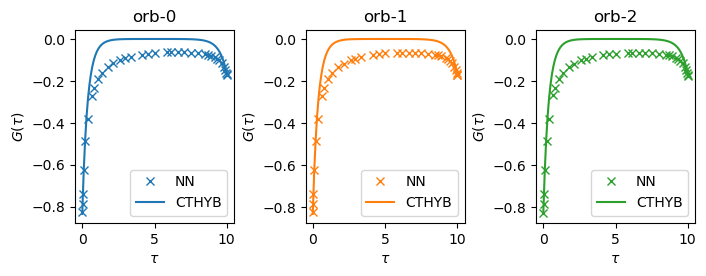

In [204]:
colors = [cm.to_hex(plt.cm.tab10(i)) for i in range(n_orb)]
lines = ['-', '--']

fig, axs = plt.subplots(1, 3, figsize=(8,2.5), dpi=100)
plt.subplots_adjust(wspace=0.45)
for orb in range(3):
    ax=axs[orb]
    ax.set_title(f'orb-{orb}')

    ax.oplot(G_tau['up'][orb,orb].real, color=colors[orb], linestyle=lines[0], label=f'NN') 
    ax.plot(taus, vals[:,orb,orb], '--', color=colors[orb], linestyle=lines[0], label=f'CTHYB') 
    
    ax.set_xlabel(r"$\tau$") 
    ax.set_ylabel(r"$G(\tau)$")
    ax.legend(loc='lower right')

We can see that the neural network test on this parameter set has some error, while the density measured from $G(\beta)$ is in good agreement. More detailed analysis on the state - whether it is insulating or metallic or how correlated the state is - can be further done by investigating the local Green's function on Matsubara frequency axis $G(i\omega)$ or the self-energy $\Sigma(i\omega)$. Here we will also compare $G(i\omega)$. While $G(\tau)$ (hence $G(i\omega)$ is in less agreement, we can start from this NN solution and run a few iterations of CTHYB, which can accelearte the DMFT calculation.

In [205]:
ioms = np.load('ioms.npy')
G_iom_vals = np.load('G_iw_imfreq.npy')

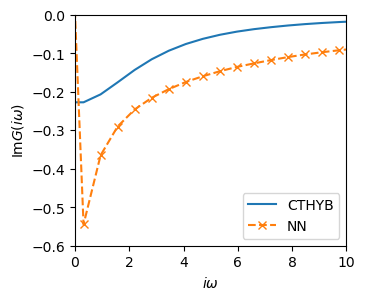

In [206]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=100)
ax.plot(ioms.imag, G_iom_vals[:,0,0], label='CTHYB')
ax.oplot(G_iw_imfreq['up'][0,0].imag, 'x', linestyle='--', label=f'NN')
ax.set_xlim(0,10)
ax.set_ylim(-0.6,0)
ax.set_xlabel(r'$i\omega$')
ax.set_ylabel(r'Im$G(i\omega)$')
ax.legend(loc='lower right')
